# Option B — SOC-Range Normalization

This notebook reads the user-provided `soc_model_results_2.csv` and generates `option_B_soc_range_output.csv`.

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

INPUT = Path("soc_model_results_2.csv")
df_raw = pd.read_csv(INPUT)

def find_col(candidates):
    lookup = {
        c.lower().replace(" ","").replace("_","").replace("-",""): c
        for c in df_raw.columns
    }
    for candidate in candidates:
        key = candidate.lower().replace(" ","").replace("_","").replace("-","")
        if key in lookup:
            return lookup[key]
    return None

def get_required(candidates, label):
    c = find_col(candidates)
    if c is None:
        raise ValueError(f"Missing required column '{label}'. Available: {list(df_raw.columns)}")
    return c

algorithm_col = get_required(["algorithm","model","regressor"], "algorithm")
r2_col = get_required(["r2"], "r2")
rmse_col = get_required(["rmse"], "rmse")
mae_col = get_required(["mae"], "mae")
pearson_col = get_required(["pearson","correlation"], "pearson")
bias_col = get_required(["bias"], "bias")

feature_col = find_col(["Feature Origin","feature_origin","featureorigin","origin"])
category_col = find_col(["category","land_use","landuse","land-use"])
soc_min_col = find_col(["soc_min","socmin"])
soc_max_col = find_col(["soc_max","socmax"])
soc_range_col = find_col(["soc_range","socrange"])
category_n_col = find_col(["category_n","sample_size","n"])
soc_mean_col = find_col(["soc_mean","socmean"])

df = pd.DataFrame({
    "algorithm": df_raw[algorithm_col],
    "Feature Origin": df_raw[feature_col] if feature_col else "",
    "r2": pd.to_numeric(df_raw[r2_col], errors="coerce"),
    "rmse": pd.to_numeric(df_raw[rmse_col], errors="coerce"),
    "mae": pd.to_numeric(df_raw[mae_col], errors="coerce"),
    "pearson": pd.to_numeric(df_raw[pearson_col], errors="coerce"),
    "bias": pd.to_numeric(df_raw[bias_col], errors="coerce"),
    "category": df_raw[category_col] if category_col else "All"
})

for name, col in [("soc_min",soc_min_col),("soc_max",soc_max_col),
                  ("soc_range",soc_range_col),("category_n",category_n_col),
                  ("soc_mean",soc_mean_col)]:
    df[name] = pd.to_numeric(df_raw[col], errors="coerce") if col else np.nan

if soc_range_col is None:
    df["soc_range"] = df["soc_max"] - df["soc_min"]

display(df.head())
print("Input columns:", list(df_raw.columns))

,algorithm,Feature Origin,r2,rmse,mae,pearson,bias,category,soc_min,soc_max,soc_range,category_n,soc_mean
0,AdaBoostRegressor,AlphaEarth,0.92,41.52,22.95,0.96,0.34,Oats,14.7,45.2,30.5,4,NaN
1,AdaBoostRegressor,AlphaEarth,0.92,41.52,22.95,0.96,0.34,Oats,14.7,45.2,30.5,4,NaN
2,GradientBoostingRegressor,AlphaEarth,0.75,54.58,20.55,0.87,-9.18,Oats,14.7,45.2,30.5,4,NaN
3,VotingRegressor,AlphaEarth,0.73,53.40,22.17,0.85,-6.64,Oats,14.7,45.2,30.5,4,NaN
4,RandomForestRegressor,AlphaEarth,0.66,54.67,21.42,0.81,-7.91,Oats,14.7,45.2,30.5,4,NaN


Input columns: ['category', 'model', 'FeatureOrigin', 'r2', 'rmse', 'mae', 'pearson', 'bias', 'soc_min', 'soc_max', 'category_n', 'soc_range', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14']


## SOC-range normalization

For each category:

\[
R_C=SOC_{\max,C}-SOC_{\min,C}
\]

\[
nRMSE_C=\frac{RMSE_C}{R_C},\quad
nMAE_C=\frac{MAE_C}{R_C},\quad
nBias_C=\frac{|Bias_C|}{R_C}.
\]

Then:

\[
S_{R^2}=\max(0,R^2),\quad
S_{RMSE}=\max(0,1-nRMSE),
\]

\[
S_{MAE}=\max(0,1-nMAE),\quad
S_P=\frac{P+1}{2},\quad
S_{Bias}=\max(0,1-nBias).
\]

In [47]:
valid = df["soc_range"].notna() & (df["soc_range"] > 0)

df["normalization_status"] = np.where(
    valid,
    "SOC-range normalized",
    "SOC-range unavailable/invalid"
)

df["nRMSE"] = np.where(valid, df["rmse"] / df["soc_range"], np.nan)
df["nMAE"] = np.where(valid, df["mae"] / df["soc_range"], np.nan)
df["nBias"] = np.where(valid, df["bias"].abs() / df["soc_range"], np.nan)

df["S_R2"] = np.maximum(0, df["r2"])
df["S_RMSE"] = np.where(valid, np.maximum(0, 1 - df["nRMSE"]), np.nan)
df["S_MAE"] = np.where(valid, np.maximum(0, 1 - df["nMAE"]), np.nan)
df["S_Pearson"] = (df["pearson"] + 1) / 2
df["S_Bias"] = np.where(valid, np.maximum(0, 1 - df["nBias"]), np.nan)

df["Score"] = df[
    ["S_R2","S_RMSE","S_MAE","S_Pearson","S_Bias"]
].mean(axis=1, skipna=False)

df["Global_Rank"] = df["Score"].rank(ascending=False, method="min").astype("Int64")
df["Category_Rank"] = df.groupby("category")["Score"].rank(
    ascending=False, method="min"
).astype("Int64")

output_cols = [
    "algorithm","Feature Origin","r2","rmse","mae","pearson","bias",
    "soc_min","soc_max","soc_range","category_n","soc_mean",
    "normalization_status","nRMSE","nMAE","nBias",
    "S_R2","S_RMSE","S_MAE","S_Pearson","S_Bias",
    "Score","Global_Rank","Category_Rank"
]

option_B_output = df[output_cols].copy()
option_B_output.to_csv(
    "option_B_soc_range_output.csv",
    index=False, encoding="utf-8-sig"
)
display(option_B_output.round(4))

output_cols_1 = [
    "algorithm","Feature Origin","category","r2","rmse","mae","pearson","bias",
    "soc_range","category_n", "Score"
]

option_B_output = df[output_cols_1].copy()
option_B_output.to_csv(
    "option_B_model_relative_minmax_output_art.csv",
    index=False, encoding="utf-8-sig"
)
display(option_B_output.round(4))

,algorithm,Feature Origin,r2,rmse,mae,pearson,bias,soc_min,soc_max,soc_range,...,nMAE,nBias,S_R2,S_RMSE,S_MAE,S_Pearson,S_Bias,Score,Global_Rank,Category_Rank
0,AdaBoostRegressor,AlphaEarth,0.92,41.52,22.95,0.96,0.34,14.7,45.2,30.5,...,0.7525,0.0111,0.92,0.0000,0.2475,0.980,0.9889,0.6273,226,2
1,AdaBoostRegressor,AlphaEarth,0.92,41.52,22.95,0.96,0.34,14.7,45.2,30.5,...,0.7525,0.0111,0.92,0.0000,0.2475,0.980,0.9889,0.6273,226,2
2,GradientBoostingRegressor,AlphaEarth,0.75,54.58,20.55,0.87,-9.18,14.7,45.2,30.5,...,0.6738,0.3010,0.75,0.0000,0.3262,0.935,0.6990,0.5420,231,5
3,VotingRegressor,AlphaEarth,0.73,53.40,22.17,0.85,-6.64,14.7,45.2,30.5,...,0.7269,0.2177,0.73,0.0000,0.2731,0.925,0.7823,0.5421,230,4
4,RandomForestRegressor,AlphaEarth,0.66,54.67,21.42,0.81,-7.91,14.7,45.2,30.5,...,0.7023,0.2593,0.66,0.0000,0.2977,0.905,0.7407,0.5207,232,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,VotingRegressor,Sentinel + AlphaEarth,0.25,27.13,19.76,0.50,9.42,3.3,510.7,507.4,...,0.0389,0.0186,0.25,0.9465,0.9611,0.750,0.9814,0.7778,65,2
242,GradientBoostingRegressor,AlphaEarth,0.25,72.12,50.39,0.50,-1.45,8.9,446.2,437.3,...,0.1152,0.0033,0.25,0.8351,0.8848,0.750,0.9967,0.7433,123,3
243,GradientBoostingRegressor,Sentinel + AlphaEarth,0.25,72.12,50.39,0.50,-1.45,8.9,446.2,437.3,...,0.1152,0.0033,0.25,0.8351,0.8848,0.750,0.9967,0.7433,123,3
244,ExtraTreesRegressor,Sentinel + AlphaEarth,0.25,34.27,22.69,0.50,-7.19,7.5,197.0,189.5,...,0.1197,0.0379,0.25,0.8192,0.8803,0.750,0.9621,0.7323,143,23


,algorithm,Feature Origin,category,r2,rmse,mae,pearson,bias,soc_range,category_n,Score
0,AdaBoostRegressor,AlphaEarth,Oats,0.92,41.52,22.95,0.96,0.34,30.5,4,0.6273
1,AdaBoostRegressor,AlphaEarth,Oats,0.92,41.52,22.95,0.96,0.34,30.5,4,0.6273
2,GradientBoostingRegressor,AlphaEarth,Oats,0.75,54.58,20.55,0.87,-9.18,30.5,4,0.5420
3,VotingRegressor,AlphaEarth,Oats,0.73,53.40,22.17,0.85,-6.64,30.5,4,0.5421
4,RandomForestRegressor,AlphaEarth,Oats,0.66,54.67,21.42,0.81,-7.91,30.5,4,0.5207
...,...,...,...,...,...,...,...,...,...,...,...
241,VotingRegressor,Sentinel + AlphaEarth,Grassland without tree/shrub cover,0.25,27.13,19.76,0.50,9.42,507.4,625,0.7778
242,GradientBoostingRegressor,AlphaEarth,Other coniferous woodland,0.25,72.12,50.39,0.50,-1.45,437.3,10,0.7433
243,GradientBoostingRegressor,Sentinel + AlphaEarth,Other coniferous woodland,0.25,72.12,50.39,0.50,-1.45,437.3,10,0.7433
244,ExtraTreesRegressor,Sentinel + AlphaEarth,Shrubland without tree cover,0.25,34.27,22.69,0.50,-7.19,189.5,7,0.7323


## Ranking and visualization

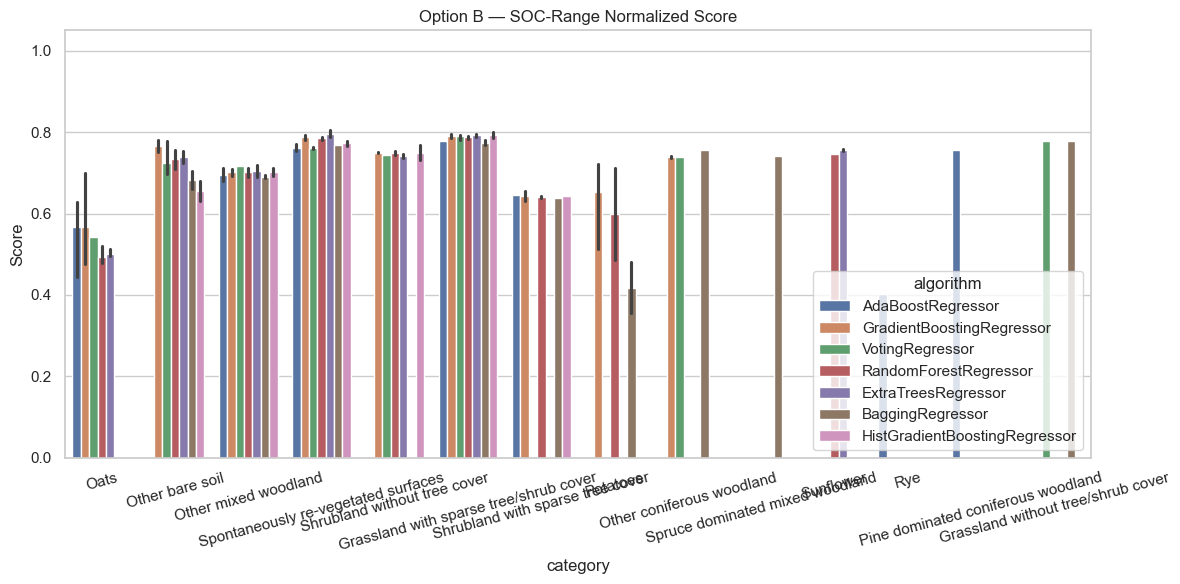

In [48]:
fig, ax = plt.subplots(figsize=(12,6))
sns.barplot(data=option_B_output, x="category", y="Score", hue="algorithm", ax=ax)
ax.set_ylim(0,1.05)
ax.set_title("Option B — SOC-Range Normalized Score")
ax.set_ylabel("Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()